In [5]:
%load_ext autoreload
%autoreload 2

# Imports :

In [6]:
import os
import pandas as pd
import networkx as nx
from matplotlib import pyplot as plt
from graphs import load_graphs, ground_truth
from corpus import Corpus
from llms_langchain import OllamaLLM

from eval import (
    add_ground_truth, add_correctness, parse_rate,
    full_report, accuracy_by,
    plot_accuracy_bar, plot_heatmap,
    plot_error_distribution, plot_confusion_per_problem,
)

RESULTS_PATH = "results/llama3.1_8b_results.csv"

import logging
logging.basicConfig(level=logging.INFO, format="%(message)s")



In [7]:

graphs_to_use = [
    #"Karate Club",
    #"Les Miserables",
    "Petersen",
    #"Florentine Families"
]
descriptors_to_use = {
    "text",                 
    "adjacency_list",
    "edge_list",
    "gml",
    "graphml"
}

os.makedirs("results", exist_ok=True)
graphs = load_graphs(graphs_to_use)
corpus = Corpus()
corpus.build(graphs, descriptors_to_use)



Corpus(graphs=['Petersen'], formats=['text', 'adjacency_list', 'edge_list', 'gml', 'graphml'], path='results/graphs_translation.json')

# GDL format :

In [8]:
# corpus.get("Florentine Families") # all formats for one graph

for graph_name, formats in corpus:
    print(f"\n{'*' * 60}")
    print(f"GRAPH: {graph_name}")
    print(f"{'*' * 60}")

    for fmt, text in formats.items():
        print(f"\n{'=' * 60}")
        print(f"FORMAT: {fmt.upper()}")
        print('=' * 60)
        print(text[:800] + ("..." if len(text) > 800 else ""))



************************************************************
GRAPH: Petersen
************************************************************

FORMAT: TEXT
Graph 'Petersen':
Node 0 → 1, 4, 5.
Node 1 → 0, 2, 6.
Node 2 → 1, 3, 7.
Node 3 → 2, 4, 8.
Node 4 → 0, 3, 9.
Node 5 → 0, 7, 8.
Node 6 → 1, 8, 9.
Node 7 → 2, 5, 9.
Node 8 → 3, 5, 6.
Node 9 → 4, 6, 7.

FORMAT: ADJACENCY_LIST
Graph 'Petersen' adjacency list:
0: 1 4 5
1: 0 2 6
2: 1 3 7
3: 2 4 8
4: 0 3 9
5: 0 7 8
6: 1 8 9
7: 2 5 9
8: 3 5 6
9: 4 6 7

FORMAT: EDGE_LIST
Graph 'Petersen' edge list:
0 -- 1
0 -- 4
0 -- 5
1 -- 2
1 -- 6
2 -- 3
2 -- 7
3 -- 4
3 -- 8
4 -- 9
5 -- 7
5 -- 8
6 -- 8
6 -- 9
7 -- 9

FORMAT: GML
# Graph 'Petersen'
graph [
  name "Petersen Graph"
  node [
    id 0
    label "0"
  ]
  node [
    id 1
    label "1"
  ]
  node [
    id 2
    label "2"
  ]
  node [
    id 3
    label "3"
  ]
  node [
    id 4
    label "4"
  ]
  node [
    id 5
    label "5"
  ]
  node [
    id 6
    label "6"
  ]
  node [
    id 7
    label "7"
  

Use few shot in order to see if it would give better results.

Autres gdls (Random walk), autre types de graphs (Weighted, not connected), LLM finetune sur les graphs (HuggingFace, look up messages github repo)
GraphLearning :
     CLassification des noeuds avec DeepWAlk , node2vec, dataset Cora .
      CLassification des noeuds avec GCN: graph convolution network meme dataset Quora.
Aprés avoir reucuperer les representations de ces (deepwalk, et node2vec), on les passe pour classifier avec LLM (Soft prompting).

Use Chroma to stock the embeddings.

POur slides and papers :
Decortiquer la figure 2 de SUrvey.( voir l'usage de LLM avec GNN) for each domain of the 3, essaye de approfondir plus sur les papers/approches utilisées.

Graph Learning, Graph representation (TRy understanding them more)

Prepare this results(Le rapport) in slides.

SO next reunion : le 28 à 10:30 à l'univ.
Link : https://univ-artois-fr.zoom.us/j/96258340903?pwd=oBsLdeEe39EJkcQ57w6quIwCMWEOaP.1
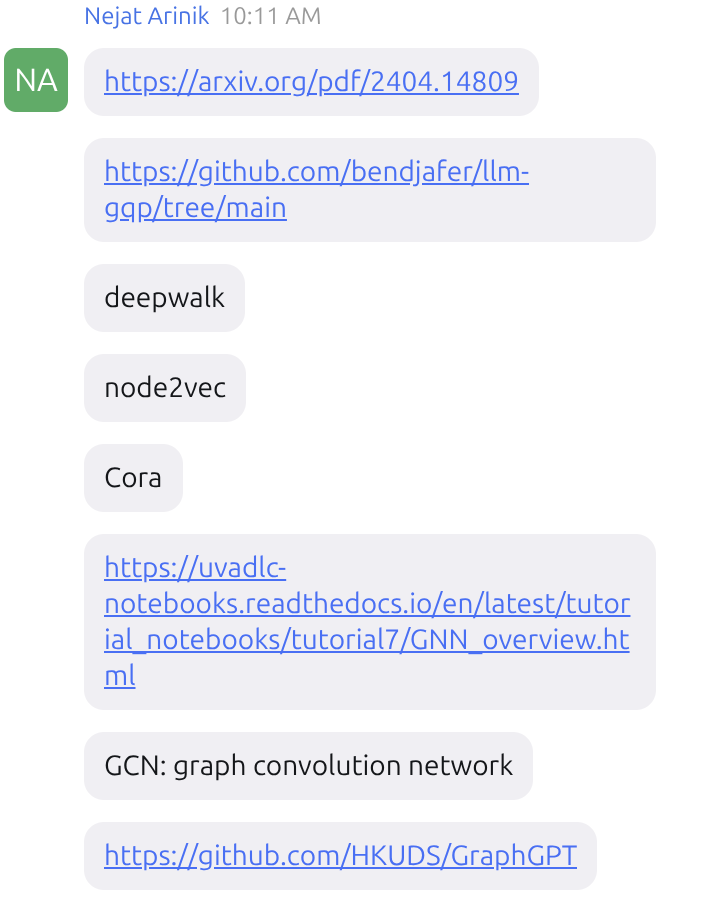

## Model & result path
Print the active Ollama model name and the CSV file that will be loaded.

In [9]:
from config import OLLAMA_MODEL
print(f"Model : {OLLAMA_MODEL}")
print(f"Results CSV: {RESULTS_PATH}")

Model : llama3.1:8b
Results CSV: results/llama3.1_8b_results.csv


## Graph used in this experiment
Draw every graph that was selected in `graphs_to_use` so the topology is visible.

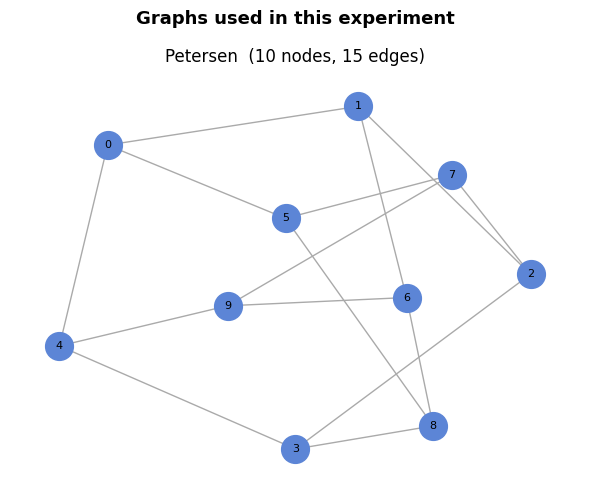

In [10]:
fig, axes = plt.subplots(1, len(graphs), figsize=(6 * len(graphs), 5))
if len(graphs) == 1:
    axes = [axes]
for ax, (name, G) in zip(axes, graphs.items()):
    nx.draw_spring(G, ax=ax, with_labels=True, node_size=400,
                   node_color='#5c85d6', edge_color='#aaaaaa', font_size=8)
    ax.set_title(f"{name}  ({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)")
plt.suptitle("Graphs used in this experiment", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Load results CSV
Read the raw LLM responses written by the orchestrator and preview the first rows.

In [17]:
df = pd.read_csv(RESULTS_PATH)
print(f"{len(df)} rows  ·  columns: {list(df.columns)}")
df.head()

50 rows  ·  columns: ['graph_name', 'format', 'problem', 'reasoning', 'answer', 'ground_truth', 'answer_parsed', 'correct']


,graph_name,format,problem,reasoning,answer,ground_truth,answer_parsed,correct
0,Petersen,text,node_count,The Petersen graph has 10 nodes. Each node is ...,10,10,10,True
1,Petersen,text,edge_count,To find the number of edges in the Petersen gr...,15,15,15,True
2,Petersen,text,neighbors,The graph has a clear structure with nodes con...,"[1, 4, 5]","[1, 4, 5]","[1, 4, 5]",True
3,Petersen,text,degree,The degree of a node in an undirected graph is...,3,3,3,True
4,Petersen,text,shortest_path,To find the shortest path from Node 0 (the fir...,No answer found,"[0, 4, 9]",NaN,NaN


## Attach ground truth
Compute the correct answer for every (graph, problem) pair and add it as a new column.

In [12]:
df = add_ground_truth(df, graphs)
df[["graph_name", "format", "problem", "answer", "ground_truth"]].head(10)

,graph_name,format,problem,answer,ground_truth
0,Petersen,text,node_count,10,10
1,Petersen,text,edge_count,15,15
2,Petersen,text,neighbors,"[1, 4, 5]","[1, 4, 5]"
3,Petersen,text,degree,3,3
4,Petersen,text,shortest_path,No answer found,"[0, 4, 9]"
5,Petersen,text,clustering,No answer found,0
6,Petersen,text,diameter,No answer found,2
7,Petersen,text,density,0.3333,0.3333
8,Petersen,text,is_connected,False,True
9,Petersen,text,cycle,True,True


## Score correctness
Parse the LLM answer and compare it to the ground truth to produce a `correct` column.

In [13]:
df = add_correctness(df)
parse_rate(df)

valid = df.dropna(subset=["correct"])
overall = valid["correct"].mean() * 100
print(f"\nOverall accuracy (parseable rows only): {overall:.2f}%")
print(f"  Correct    : {int(valid['correct'].sum())}")
print(f"  Wrong      : {int((valid['correct'] == False).sum())}")
print(f"  Unparseable: {int(df['correct'].isna().sum())}")

Parse rate: 43/50 (86.0%)

Overall accuracy (parseable rows only): 67.44%
  Correct    : 29
  Wrong      : 14
  Unparseable: 7


## Full evaluation report
Print accuracy broken down by problem, by descriptor format, and by graph name.

In [14]:
full_report(df)

EVALUATION REPORT
Total rows : 50
Correct answers : 29
Unparseable answers : 7
Overall accuracy : 67.44% (excl. unparseable)

── BY PROBLEM ────────────────────────────────────────
problem
clustering         0.0
cycle             60.0
degree           100.0
density           40.0
diameter          50.0
edge_count        60.0
is_connected      80.0
neighbors        100.0
node_count       100.0
shortest_path      0.0

── BY FORMAT ─────────────────────────────────────────
format
adjacency_list    66.67
edge_list          62.5
gml                70.0
graphml           55.56
text              85.71

── BY GRAPH ──────────────────────────────────────────
graph_name
Petersen    67.44

── ERROR EXAMPLES ──────────────────────────────────────────
graph_name         format       problem         answer_parsed ground_truth
  Petersen           text  is_connected                 False         True
  Petersen adjacency_list shortest_path [0, 1, 6, 8, 3, 4, 9]    [0, 4, 9]
  Petersen adjacency_list 

## Accuracy charts
Visualise accuracy per problem and per format, then show a problem × format heatmap and the stacked answer-distribution bar chart.

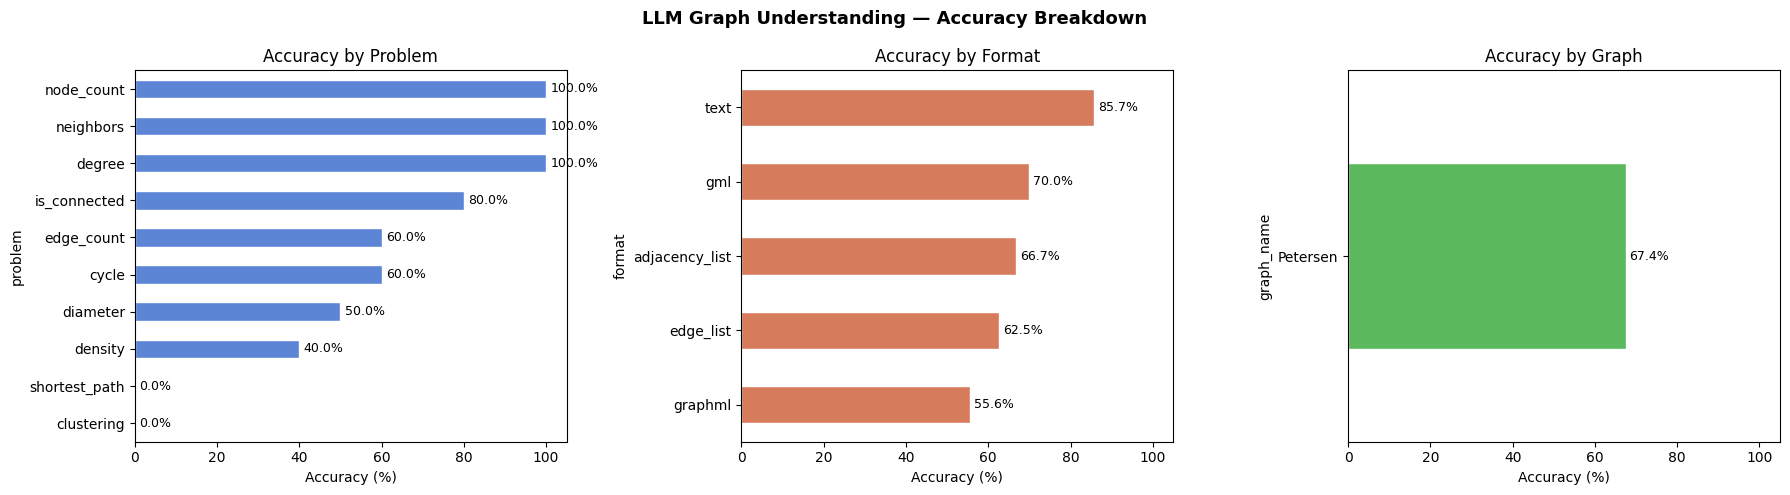

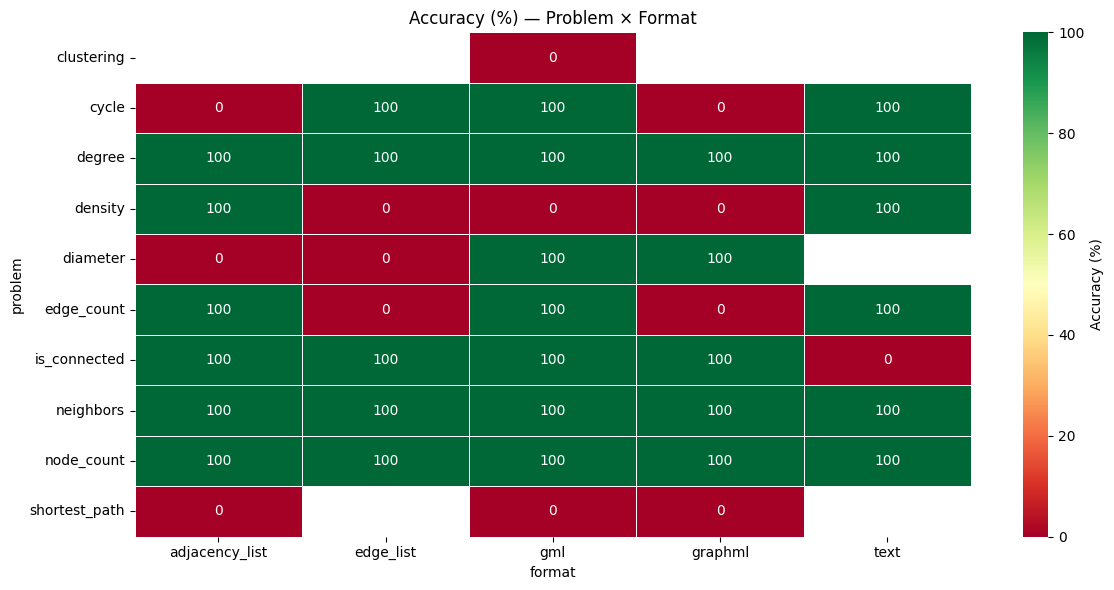

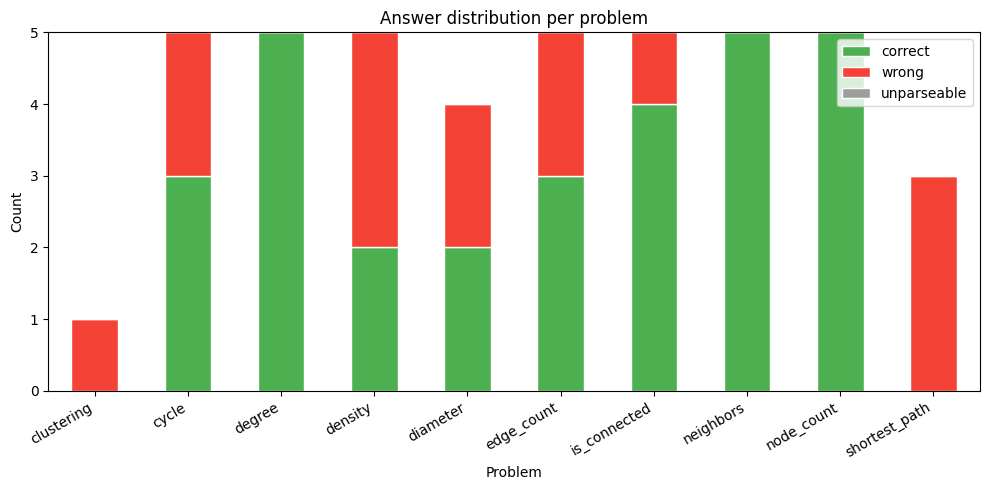

In [15]:
# ── Bar charts: problem / format / graph ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_accuracy_bar(df, "problem",    "Accuracy by Problem",  ax=axes[0], color="#5c85d6")
plot_accuracy_bar(df, "format",     "Accuracy by Format",   ax=axes[1], color="#d67c5c")
plot_accuracy_bar(df, "graph_name", "Accuracy by Graph",    ax=axes[2], color="#5cb85c")
plt.suptitle("LLM Graph Understanding — Accuracy Breakdown", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/accuracy_bars.png", dpi=150)
plt.show()

# ── Problem × Format heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
plot_heatmap(df, row_col="problem", col_col="format",
             title="Accuracy (%) — Problem × Format", ax=ax)
plt.savefig("results/heatmap_problem_format.png", dpi=150)
plt.show()

# ── Stacked answer-distribution bar ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
plot_error_distribution(df, ax=ax)
plt.savefig("results/error_distribution.png", dpi=150)
plt.show()

# Wrong answer case :

In [ ]:
# ── Pick the first wrong row ──────────────────────────────────────────────
wrong = df[df["correct"] == False].reset_index(drop=True)

if wrong.empty:
    print("No wrong answers found — the LLM got everything right!")
else:
    row = wrong.iloc[0]  
    #row = wrong[wrong["problem"] == "clustering"].iloc[0]

    graph_name = row["graph_name"]
    fmt        = row["format"]
    problem    = row["problem"]

    # Reconstruct the exact prompt that was sent to the model
    graph_description = corpus.get(graph_name, fmt)
    from prompts import ROLE_AND_RULES, PROMPT_TEMPLATE
    from config import P_PROBLEMS_PROMPTS
    question = P_PROBLEMS_PROMPTS[problem]

    print(f"Graph   : {graph_name}")
    print(f"Format  : {fmt}")
    print(f"Problem : {problem}")
    print()
    print("=" * 60)
    print("SYSTEM PROMPT")
    print("=" * 60)
    print(ROLE_AND_RULES)
    print()
    print("=" * 60)
    print("USER PROMPT")
    print("=" * 60)
    print(PROMPT_TEMPLATE.format(description=graph_description, question=question))
    print()
    print("=" * 60)
    print("LLM REASONING")
    print("=" * 60)
    print(row["reasoning"])
    print()
    print("=" * 60)
    print(f"LLM ANSWER    : {row['answer_parsed']}")
    print(f"GROUND TRUTH  : {row['ground_truth']}")
    print(f"CORRECT       : {row['correct']}")
    print("=" * 60)


Graph   : Petersen
Format  : text
Problem : is_connected

SYSTEM PROMPT
You are an expert graph theorist and data scientist.
You analyze undirected, unweighted graphs precisely.

Output the final answer strictly after the separator.

Format:
[your reasoning on why you chose that answer]
###ANSWER###
[your final answer only]

Rules:
- After ###ANSWER###, output only the final answer.
- Do not repeat the question.
- Do not add labels like Answer: or any explanation after ###ANSWER###.
- Never leave the ###ANSWER### block empty.
- Use the graph exactly as given. Do not invent edges or nodes.
- The graph is undirected and unweighted unless explicitly stated otherwise.
- Count each undirected edge exactly once.

Format-specific reading rules:
- Use the literal node identifiers exactly as shown.

Answer format rules:
- node_count / edge_count / degree / diameter:
  integer only
- neighbors:
  Python list using the exact node identifiers from the graph
- shortest_path:
  Python list containin